In [1]:
import numpy as np

X_train_smote = np.load(
    "C:/Users/HIII/banking-fraud-detection/data/X_train_smote.npy"
)

X_test_scaled = np.load(
    "C:/Users/HIII/banking-fraud-detection/data/X_test_scaled.npy"
)

y_train_smote = np.load(
    "C:/Users/HIII/banking-fraud-detection/data/y_train_smote.npy"
)

y_test = np.load(
    "C:/Users/HIII/banking-fraud-detection/data/y_test.npy"
)

# TRAIN LOGISTIC REGRESSION

In [2]:
from sklearn.linear_model import LogisticRegression


In [3]:
model = LogisticRegression(random_state=42)

model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [4]:
y_pred = model.predict(X_test_scaled)


In [5]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



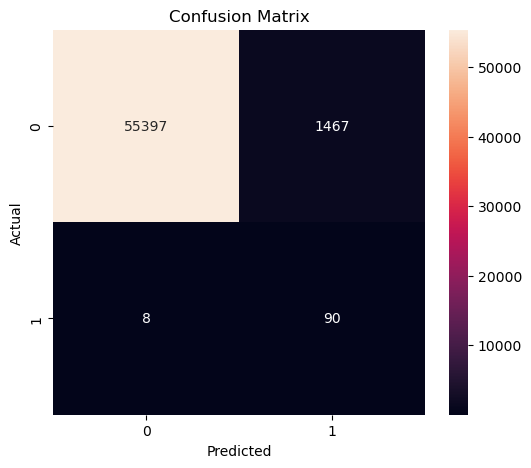

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [7]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_pred)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9462844753827248


# RANDOM FOREST IMPLEMENTATION

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1

)

rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,20
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
rf_pred = rf_model.predict(X_test_scaled)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.41      0.84      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.92      0.77     56962
weighted avg       1.00      1.00      1.00     56962



In [13]:
from sklearn.metrics import roc_auc_score

rf_roc = roc_auc_score(y_test, rf_pred)

print("Random Forest ROC-AUC:", rf_roc)

Random Forest ROC-AUC: 0.9173121978110321


In [14]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

### Logistic regression metrics

In [15]:
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_roc = roc_auc_score(y_test, y_pred)

In [18]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_pred)

### Random Forest Metrics

In [19]:
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_roc = roc_auc_score(y_test, y_pred)

### Comparison

In [20]:
print("Logistic Regression Performance")
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)
print("ROC-AUC:", lr_roc)

print("\n---------------------------\n")

print("Random Forest Performance")
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("ROC-AUC:", rf_roc)

Logistic Regression Performance
Precision: 0.057803468208092484
Recall: 0.9183673469387755
F1 Score: 0.10876132930513595
ROC-AUC: 0.9462844753827248

---------------------------

Random Forest Performance
Precision: 0.40594059405940597
Recall: 0.8367346938775511
F1 Score: 0.5466666666666666
ROC-AUC: 0.9173121978110321


In [21]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1],
    "ROC-AUC": [lr_roc, rf_roc]
})

comparison_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.057803,0.918367,0.108761,0.946284
1,Random Forest,0.405941,0.836735,0.546667,0.917312


# Model Comparison and Evaluation

Two machine learning models were trained and evaluated for banking fraud detection:

1. Logistic Regression
2. Random Forest Classifier

The models were evaluated using the following metrics:
- Precision
- Recall
- F1-score
- ROC-AUC

---

# Logistic Regression

## Advantages
- Achieved extremely high recall.
- Successfully detected most fraudulent transactions.
- Simple and computationally efficient.
- Easy to interpret and explain.

## Weaknesses
- Very low precision.
- Generated many false positives.
- Many legitimate transactions were incorrectly flagged as fraud.

## Interpretation
Logistic Regression is highly aggressive in fraud detection. 
While it captures most fraud cases, it also produces many false alarms, which may increase operational costs in real banking environments.

---

# Random Forest Classifier

## Advantages
- Achieved significantly better precision.
- Produced a much stronger F1-score.
- Better balance between fraud detection and false positives.
- Handles complex and nonlinear fraud patterns effectively.

## Weaknesses
- Slightly lower recall than Logistic Regression.
- More computationally expensive.
- Less interpretable compared to Logistic Regression.

## Interpretation
Random Forest demonstrated a better overall balance between detecting fraud and minimizing false alarms. 
It provides more practical performance for real-world banking fraud detection systems.

---

# Best Performing Model

## Selected Model: Random Forest Classifier

Random Forest was selected as the best model because it achieved:
- Much higher precision,
- Better F1-score,
- Strong fraud detection capability,
- Better balance between recall and false positives.

Although Logistic Regression achieved slightly higher recall, its extremely low precision makes it less practical for real banking operations where excessive false alerts can increase investigation costs and negatively affect customer experience.

Therefore, Random Forest is the preferred model for this banking fraud detection system.

In [22]:
import joblib

joblib.dump(
    rf_model,
    "C:/Users/HIII/banking-fraud-detection/models/random_forest_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


# Final Project Conclusion

This project developed a machine learning pipeline for banking fraud detection using the Credit Card Fraud Detection dataset.

The project included:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature scaling
- Class imbalance handling using SMOTE
- Machine learning model training and evaluation

Two supervised learning models were evaluated:
1. Logistic Regression
2. Random Forest Classifier

The models were compared using:
- Precision
- Recall
- F1-score
- ROC-AUC

Random Forest achieved the best overall performance by providing a strong balance between fraud detection capability and reduction of false positives.

This project demonstrates the practical application of machine learning in financial fraud detection systems.